In [240]:
# Paqueterias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error

In [241]:
# Cargar datos con csv

ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Datos/casos_dengue_2020-2025.csv"
df = pd.read_csv(ruta)
df.head()

,FECHA,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COLIMA,DISTRITO FEDERAL,...,QUINTANA ROO,SAN LUIS POTOSI,SINALOA,SONORA,TABASCO,TAMAULIPAS,TLAXCALA,VERACRUZ,YUCATAN,ZACATECAS
0,2020-01-05,0,2,4,36,41,1,4,23,6,...,106,47,40,8,112,111,0,249,58,3
1,2020-01-12,0,2,3,37,83,5,1,37,6,...,167,74,46,13,158,206,0,441,62,0
2,2020-01-19,0,0,3,31,73,0,4,40,2,...,158,80,48,12,166,190,0,412,73,2
3,2020-01-26,1,1,2,45,57,0,1,39,3,...,130,53,54,13,167,191,1,418,54,1
4,2020-02-02,0,0,2,40,54,0,1,32,0,...,99,43,48,9,139,173,1,322,45,1


In [242]:
cols_municipios = ['AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR',
       'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA',
       'DISTRITO FEDERAL', 'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO',
       'JALISCO', 'MEXICO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON',
       'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI',
       'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ',
       'YUCATAN', 'ZACATECAS']

In [243]:
df["FECHA"] = pd.to_datetime(df["FECHA"])

df["casos_semana"] = df[cols_municipios].sum(axis=1)

df[["FECHA", "casos_semana"]]

,FECHA,casos_semana
0,2020-01-05,1318
1,2020-01-12,2068
2,2020-01-19,2078
3,2020-01-26,1973
4,2020-02-02,1562
...,...,...
277,2025-04-27,1504
278,2025-05-04,1549
279,2025-05-11,1878
280,2025-05-18,1932


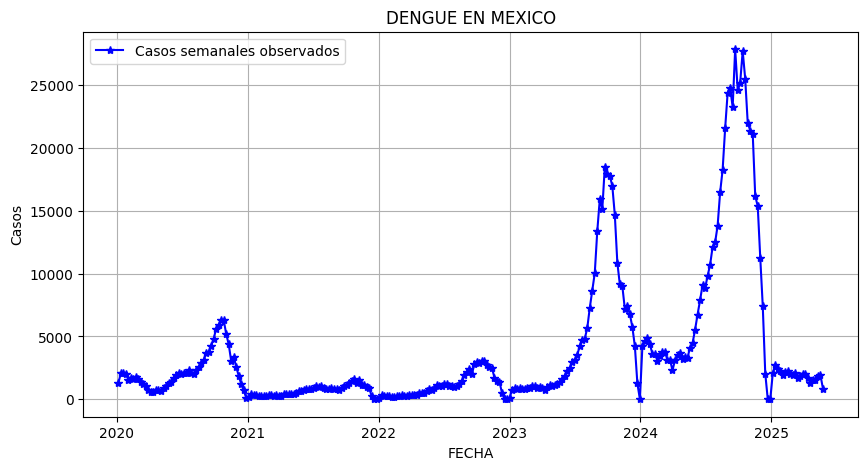

In [244]:
# Gráfica de la serie

plt.figure(figsize=(10, 5), dpi=100)

plt.plot(
    df["FECHA"],
    df["casos_semana"],
    marker="*",
    label="Casos semanales observados",
    color='blue'
)

plt.xlabel("FECHA")
plt.ylabel("Casos")
plt.title("DENGUE EN MEXICO")
plt.xticks()
plt.legend()
plt.grid()

plt.show()

**Interpretación** (RESPUESTAS)

* _¿Se observan picos de casos?_

    Sí, podemos ver que hay algunos picos, podemos verlos a finales del 2020, finales del 2023, y algunos más a finales del 2025.

* ¿En qué periodos parecen concentrarse los aumentos?

    Nuestros picos se presentan cerca del inicio del otoño.

* La serie parece estable o variable?

    Estable, a pesar de los altos picos registrados, mantiene una cierta tendencia a lo largo del año.

* ¿Se observa algún posible patrón estacional?

    Sí, como podemos ver, cercanos al inicio del otoño es cuando se hacen los picos, para invierno suele bajar considerablemente.

* ¿Qué dificultades podría tener un modelo para predecir esta serie?

    Que hay ciertos parámetros que no se contemplan, lo que genera una perdida de información y hace que el modelo no sea tan prreciso como necesitariamos.

.

## **Parte 2. Construcción de variables temporales**

Construyan variables predictoras usando información disponible hasta la semana (t).

Deben incluir al menos:

\begin{align}
    &C_t,\\
    C_{t-1}, C_{t-2}&, C_{t-3}, C_{t-4}\\
    MA_3,& MA_5
\end{align}

y

\begin{equation}
    \Delta C_t = C_t - C_{t-1}
\end{equation}

Donde:

* $C_t$ representa los casos de la semana actual;
* los rezagos representan casos de semanas anteriores;
* $MA_3$ y $MA_5$ son promedios moviles;
* $\Delta C_T$ representa el cambio semanal.

Después, construyan la variable objetivo para predicción:

\begin{equation}
    C_{t+1}
\end{equation}

Es decir, los casos nacionales de dengue de la siguiente semana.

Expliquen brevemente por qué estas variables pueden ser útiles para predecir la siguiente semana.

In [245]:
# Tiempo

df["FECHA"] = pd.to_datetime(df["FECHA"])

cols_municipios = [col for col in df.columns if col != "FECHA"]

df["casos_semana"] = df[cols_municipios].sum(axis=1)

df = df.sort_values("FECHA").reset_index(drop=True)

df.head()

,FECHA,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COLIMA,DISTRITO FEDERAL,...,SAN LUIS POTOSI,SINALOA,SONORA,TABASCO,TAMAULIPAS,TLAXCALA,VERACRUZ,YUCATAN,ZACATECAS,casos_semana
0,2020-01-05,0,2,4,36,41,1,4,23,6,...,47,40,8,112,111,0,249,58,3,2636
1,2020-01-12,0,2,3,37,83,5,1,37,6,...,74,46,13,158,206,0,441,62,0,4136
2,2020-01-19,0,0,3,31,73,0,4,40,2,...,80,48,12,166,190,0,412,73,2,4156
3,2020-01-26,1,1,2,45,57,0,1,39,3,...,53,54,13,167,191,1,418,54,1,3946
4,2020-02-02,0,0,2,40,54,0,1,32,0,...,43,48,9,139,173,1,322,45,1,3124


In [246]:
# Creamos nuevas columnas y las desplazamos n filas hacia abajo

# Rezagos
df["lag_1"] = df["casos_semana"].shift(1)
df["lag_2"] = df["casos_semana"].shift(2)
df["lag_3"] = df["casos_semana"].shift(3)
df["lag_4"] = df["casos_semana"].shift(4)

# Hacemos las columnas de los promedios para MA_3 y MA_5
df["promedio_movil_3"] = df["casos_semana"].rolling(window=3).mean() # Promedios móviles
df["promedio_movil_5"] = df["casos_semana"].rolling(window=5).mean()

# Cambio Semanal
df["cambio_semanal"] = df["casos_semana"].diff() # Cambio semanal

df["casos_siguiente_semana"] = df["casos_semana"].shift(-1) # Variable objetivo

df.head()

,FECHA,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COLIMA,DISTRITO FEDERAL,...,ZACATECAS,casos_semana,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,cambio_semanal,casos_siguiente_semana
0,2020-01-05,0,2,4,36,41,1,4,23,6,...,3,2636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4136.0
1,2020-01-12,0,2,3,37,83,5,1,37,6,...,0,4136,2636.0,NaN,NaN,NaN,NaN,NaN,1500.0,4156.0
2,2020-01-19,0,0,3,31,73,0,4,40,2,...,2,4156,4136.0,2636.0,NaN,NaN,3642.666667,NaN,20.0,3946.0
3,2020-01-26,1,1,2,45,57,0,1,39,3,...,1,3946,4156.0,4136.0,2636.0,NaN,4079.333333,NaN,-210.0,3124.0
4,2020-02-02,0,0,2,40,54,0,1,32,0,...,1,3124,3946.0,4156.0,4136.0,2636.0,3742.000000,3599.6,-822.0,3318.0


In [247]:
# columnas para el modelo

columnas_modelo = [
    "FECHA",
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal",
    "casos_siguiente_semana"
]

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)

df_modelo.head()

,FECHA,casos_semana,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,cambio_semanal,casos_siguiente_semana
0,2020-02-02,3124,3946.0,4156.0,4136.0,2636.0,3742.000000,3599.6,-822.0,3318.0
1,2020-02-09,3318,3124.0,3946.0,4156.0,4136.0,3462.666667,3736.0,194.0,3186.0
2,2020-02-16,3186,3318.0,3124.0,3946.0,4156.0,3209.333333,3546.0,-132.0,3512.0
3,2020-02-23,3512,3186.0,3318.0,3124.0,3946.0,3338.666667,3417.2,326.0,3196.0
4,2020-03-01,3196,3512.0,3186.0,3318.0,3124.0,3298.000000,3267.2,-316.0,2768.0


In [248]:
# Variables Predictoras

variables_predictoras = [
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal"
]

X = df_modelo[variables_predictoras]
y = df_modelo["casos_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana   lag_1   lag_2   lag_3   lag_4  promedio_movil_3  \
0          3124  3946.0  4156.0  4136.0  2636.0       3742.000000   
1          3318  3124.0  3946.0  4156.0  4136.0       3462.666667   
2          3186  3318.0  3124.0  3946.0  4156.0       3209.333333   
3          3512  3186.0  3318.0  3124.0  3946.0       3338.666667   
4          3196  3512.0  3186.0  3318.0  3124.0       3298.000000   

   promedio_movil_5  cambio_semanal  
0            3599.6          -822.0  
1            3736.0           194.0  
2            3546.0          -132.0  
3            3417.2           326.0  
4            3267.2          -316.0  
0    3318.0
1    3186.0
2    3512.0
3    3196.0
4    2768.0
Name: casos_siguiente_semana, dtype: float64


***Explicación***

Las variables $C_t, C_{t-1},\dots$ nos muestran los rezagos, lo que nos da una idea de los infectados actualmente, con los que podemos determinar a cuántos pueden contagiar.


Con los promedios moviles $MA_3$ y $MA_5$, podemos ver la tendencia de contagio, pero tomando en cuenta los casos *atipicos*, donde los casos sean demasiados o sean pocos en comparación con las semanas pasadas.



Con el cambio semanal, podemos determinar el ritmo de propagación, el cual nos dice si es acelerado o se va frenando.

.

## **Parte 3. Predicción de casos semanales**

En esta parte, el problema se considera como un problema de regresión.

La pregunta es:

\begin{equation}
    \text{¿Podemos predecir los casos nacionales de dengue la siguiente semana?}
\end{equation}

Deben dividir los datos en conjunto de entrenamiento y conjunto de prueba respetando el orden temporal. No deben mezclar las semanas de manera aleatoria.

Usen las primeras semanas para entrenamiento y las semanas finales para prueba.

Comparen al menos los siguientes modelos:

1. Modelo ingenuo.
2. Regresión lineal.
3. Árbol de decisión.
4. Random Forest.

El modelo ingenuo debe usar la regla:

\begin{equation}
    \hat{C}_{t+1} = C_t
\end{equation}

Es decir, predice que la siguiente semana tendrá el mismo número de casos que la semana actual.

Evalúen los modelos usando $MAE$ y $RMSE$.

ncluyan una tabla comparativa de modelos.

También incluyan una gráfica comparando los casos observados contra las predicciones de al menos dos modelos, incluyendo el modelo ingenuo y el mejor modelo obtenido.

En la interpretación, respondan:

* ¿Qué modelo tuvo menor MAE?
* ¿Qué modelo tuvo menor RMSE?
* ¿El modelo más complejo fue necesariamente el mejor?
* ¿Algún modelo logró mejorar al modelo ingenuo?
* ¿Qué modelo parece capturar mejor los picos?
* ¿En qué periodos se observan los mayores errores?

In [249]:
# Corte

n = len(df_modelo)

n_train = int(0.7 * n)

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["casos_siguiente_semana"]

X_test = df_test[variables_predictoras]
y_test = df_test["casos_siguiente_semana"]

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (193, 8)
Tamaño prueba: (84, 8)


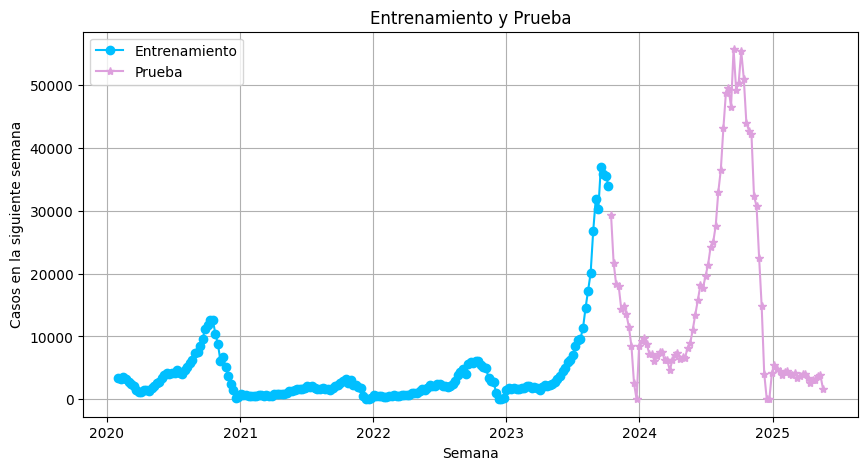

In [250]:
# Gráfica

plt.figure(figsize=(10, 5), dpi=100)

plt.plot(
    df_train["FECHA"],
    df_train["casos_siguiente_semana"],
    marker="o",
    label="Entrenamiento",
    color="deepskyblue"
)

plt.plot(
    df_test["FECHA"],
    df_test["casos_siguiente_semana"],
    marker="*",
    label="Prueba",
    color="plum"
)

plt.xlabel("Semana")
plt.ylabel("Casos en la siguiente semana")
plt.title("Entrenamiento y Prueba")
plt.xticks()
plt.legend()
plt.grid()

plt.show()

In [251]:
# Definimos nuestra función para las métricas MAE y RMSE

def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    return mae, rmse

In [252]:
# Modelo Ingenuo

df_test["pred_naive"] = df_test["casos_semana"]

mae_naive, rmse_naive = calcular_metricas(
    y_test,
    df_test["pred_naive"]
)

print("Modelo ingenuo")
print("MAE:", mae_naive)
print("RMSE:", rmse_naive)

Modelo ingenuo
MAE: 2326.7380952380954
RMSE: 3503.9364869760275


In [253]:
# Modelo de regresión lineal

modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

# Evitar predicciones negativas
pred_lr = np.maximum(pred_lr, 0)

mae_lr, rmse_lr = calcular_metricas(y_test, pred_lr)

print("Regresión lineal")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Regresión lineal
MAE: 2050.324246727248
RMSE: 2860.339011978507


In [254]:
# Modelo de regresión de árbol de deciciones

modelo_arbol = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

pred_arbol = np.maximum(pred_arbol, 0)

mae_arbol, rmse_arbol = calcular_metricas(y_test, pred_arbol)

print("Árbol de decisión")
print("MAE:", mae_arbol)
print("RMSE:", rmse_arbol)

Árbol de decisión
MAE: 5347.689209655153
RMSE: 8357.991658347075


In [255]:
# Modelo de Random Forest

modelo_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

pred_rf = np.maximum(pred_rf, 0)

mae_rf, rmse_rf = calcular_metricas(y_test, pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
MAE: 5267.240329024732
RMSE: 8162.439498627026


In [256]:
# Tabla de comparación

df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Regresión lineal",
        "Árbol de decisión",
        "Random Forest"
    ],
    "MAE": [
        mae_naive,
        mae_lr,
        mae_arbol,
        mae_rf
    ],
    "RMSE": [
        rmse_naive,
        rmse_lr,
        rmse_arbol,
        rmse_rf
    ]
})

df_metricas.sort_values("RMSE")

,modelo,MAE,RMSE
1,Regresión lineal,2050.324247,2860.339012
0,Naive,2326.738095,3503.936487
3,Random Forest,5267.240329,8162.439499
2,Árbol de decisión,5347.689210,8357.991658


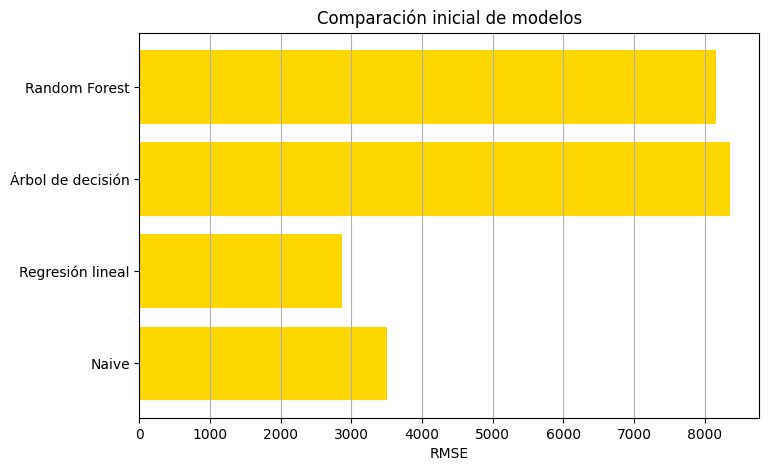

In [257]:
# Gráfica

plt.figure(figsize=(8, 5))

plt.barh(
    df_metricas["modelo"],
    df_metricas["RMSE"], color='gold'
)

plt.xlabel("RMSE")
plt.title("Comparación inicial de modelos")
plt.grid(axis="x")

plt.show()

In [258]:
# Pruebas

df_test["pred_lr"] = pred_lr
df_test["pred_arbol"] = pred_arbol
df_test["pred_rf"] = pred_rf

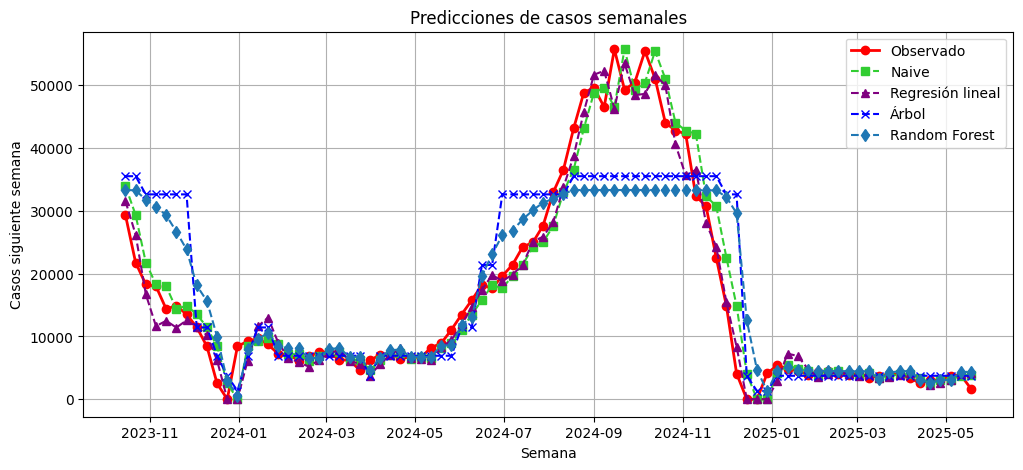

In [259]:
# Gráfica de comparación

plt.figure(figsize=(12, 5), dpi=100)

plt.plot(
    df_test["FECHA"],
    df_test["casos_siguiente_semana"],
    marker="o",
    label="Observado", color = 'red', lw=2
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_naive"],
    marker="s",
    linestyle="--",
    color='limegreen',
    label="Naive"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_lr"],
    marker="^",
    linestyle="--",
    color='purple',
    label="Regresión lineal"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_arbol"],
    marker="x",
    linestyle="--",
    color='blue',
    label="Árbol"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_rf"],
    marker="d",
    linestyle="--",
    label="Random Forest"
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("Predicciones de casos semanales")
plt.legend()
plt.grid()

plt.show()

* *¿Qué modelo tuvo menor MAE?*

    El modelo de regresión lineal.


* *¿Qué modelo tuvo menor RMSE?*

    El modelo de regresión lineal.

* *¿El modelo más complejo fue necesariamente el mejor?*

    No, ya que no fue necesario ser tan complejo en esta situación un poco más tranquila.

* *¿Algún modelo logró mejorar al modelo ingenuo?*

    Sí, en este caso el modelo de regresión lineal obtuvo mejores resultados que el *modelo ingenuo*.  

* *¿Qué modelo parece capturar mejor los picos?*

    El modelo ingenuo, se acerca bastante a los picos.

* *¿En qué periodos se observan los mayores errores?*

    En otoño del 2024.

## **Parte 4. Clasificación de semanas de riesgo**


Ahora transformen el problema en uno de **clasificación supervisada**.

En lugar de predecir el número exacto de casos, clasifiquen la siguiente semana como:

\begin{equation}
    \text{riesgo bajo}, \quad \text{riesgo medio}, \quad \text{riesgo alto}.
\end{equation}

Para construir estas categorías, usen cuantiles de la variable $(C_{t+1})$, de forma que las tres clases tengan tamaños aproximadamente similares.

Deben reportar los cortes utilizados para definir las categorías.

Por ejemplo, deben indicar algo como:

\begin{align}
    \text{bajo: de $a$ a $b$ casos},\\
    \text{medio: de $b$ a $c$ casos},\\
    \text{alto: de $c$ a $d$ casos}.
\end{align}

Revisen y reporten cuántas semanas quedaron en cada categoría.

In [260]:
cols_municipios = ['AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR',
       'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA',
       'DISTRITO FEDERAL', 'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO',
       'JALISCO', 'MEXICO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON',
       'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI',
       'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ',
       'YUCATAN', 'ZACATECAS']

In [261]:
# Datos

df["FECHA"] = pd.to_datetime(df["FECHA"])

df["casos_semana"] = df[cols_municipios].sum(axis=1)

df = df[["FECHA", "casos_semana"]].copy()

df = df.rename(columns={'FECHA': 'semana'})  #Renombramos

print("Nuevo tamaño del DataFrame:", df.shape)
print(df.head())

Nuevo tamaño del DataFrame: (282, 2)
      semana  casos_semana
0 2020-01-05          1318
1 2020-01-12          2068
2 2020-01-19          2078
3 2020-01-26          1973
4 2020-02-02          1562


In [262]:
# columnas

df["lag_1"] = df["casos_semana"].shift(1)
df["lag_2"] = df["casos_semana"].shift(2)
df["lag_3"] = df["casos_semana"].shift(3)
df["lag_4"] = df["casos_semana"].shift(4)

df["promedio_movil_3"] = df["casos_semana"].rolling(window=3).mean()
df["promedio_movil_5"] = df["casos_semana"].rolling(window=5).mean()

df["cambio_semanal"] = df["casos_semana"].diff()

df["cambio_relativo"] = (
    df["casos_semana"] - df["lag_1"]
) / df["lag_1"]

df["cambio_relativo"] = df["cambio_relativo"].replace(
    [np.inf, -np.inf],
    np.nan
)


In [263]:
df["casos_siguiente_semana"] = df["casos_semana"].shift(-1)

df.head(10)

# Tuve que jalar de nuevo toda la info, algo chocaba y me cambiaba
# los valores.

,semana,casos_semana,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,cambio_semanal,cambio_relativo,casos_siguiente_semana
0,2020-01-05,1318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2068.0
1,2020-01-12,2068,1318.0,NaN,NaN,NaN,NaN,NaN,750.0,0.569044,2078.0
2,2020-01-19,2078,2068.0,1318.0,NaN,NaN,1821.333333,NaN,10.0,0.004836,1973.0
3,2020-01-26,1973,2078.0,2068.0,1318.0,NaN,2039.666667,NaN,-105.0,-0.050529,1562.0
4,2020-02-02,1562,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8,-411.0,-0.208312,1659.0
5,2020-02-09,1659,1562.0,1973.0,2078.0,2068.0,1731.333333,1868.0,97.0,0.062100,1593.0
6,2020-02-16,1593,1659.0,1562.0,1973.0,2078.0,1604.666667,1773.0,-66.0,-0.039783,1756.0
7,2020-02-23,1756,1593.0,1659.0,1562.0,1973.0,1669.333333,1708.6,163.0,0.102323,1598.0
8,2020-03-01,1598,1756.0,1593.0,1659.0,1562.0,1649.000000,1633.6,-158.0,-0.089977,1384.0
9,2020-03-08,1384,1598.0,1756.0,1593.0,1659.0,1579.333333,1598.0,-214.0,-0.133917,1200.0


In [264]:
# Cortes

df["riesgo_siguiente_semana"], cortes = pd.qcut(
    df["casos_siguiente_semana"],
    q=3,
    labels=["bajo", "medio", "alto"],
    retbins=True
)

In [265]:
df_cortes = pd.DataFrame({
    "categoria": ["bajo", "medio", "alto"],
    "desde": [cortes[0], cortes[1], cortes[2]],
    "hasta": [cortes[1], cortes[2], cortes[3]]
})

df_cortes

,categoria,desde,hasta
0,bajo,0.000000,994.000000
1,medio,994.000000,2708.333333
2,alto,2708.333333,27869.000000


## **Parte 5. Modelos de clasificación**

Para la clasificación de riesgo, usen las mismas variables predictoras construidas previamente.

Comparen al menos los siguientes modelos:

1. Modelo ingenuo de clasificación.
2. Árbol de decisión.
3. Random Forest.


El modelo ingenuo de clasificación debe predecir que la categoría de riesgo de la siguiente semana será igual a la categoría de riesgo de la semana actual.


Evalúen los modelos usando _**Accuracy**_.


Incluyan una tabla comparativa con el accuracy de cada modelo.

Después, para al menos un modelo —preferentemente el mejor o el Random Forest— incluyan:

* matriz de confusión;
* reporte de clasificación;
* interpretación de precision;
* interpretación de recall;
* interpretación de F1-score.

In [266]:
df[["semana", "casos_semana", "casos_siguiente_semana", "riesgo_siguiente_semana"]].tail(5)

,semana,casos_semana,casos_siguiente_semana,riesgo_siguiente_semana
277,2025-04-27,1504,1549.0,medio
278,2025-05-04,1549,1878.0,medio
279,2025-05-11,1878,1932.0,medio
280,2025-05-18,1932,849.0,bajo
281,2025-05-25,849,NaN,NaN


In [267]:
# nivel de reisgo

df["riesgo_siguiente_semana"].value_counts()

,count
riesgo_siguiente_semana,
bajo,94
alto,94
medio,93


In [268]:
# columnas para el modelo

columnas_modelo = [
    "semana",
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal",
    "cambio_relativo",
    "casos_siguiente_semana",
    "riesgo_siguiente_semana"
]

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)

df_modelo.tail(5)

,semana,casos_semana,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,cambio_semanal,cambio_relativo,casos_siguiente_semana,riesgo_siguiente_semana
265,2025-04-20,1280,1693.0,1990.0,1977.0,1874.0,1654.333333,1762.8,-413.0,-0.243946,1504.0,medio
266,2025-04-27,1504,1280.0,1693.0,1990.0,1977.0,1492.333333,1688.8,224.0,0.175000,1549.0,medio
267,2025-05-04,1549,1504.0,1280.0,1693.0,1990.0,1444.333333,1603.2,45.0,0.029920,1878.0,medio
268,2025-05-11,1878,1549.0,1504.0,1280.0,1693.0,1643.666667,1580.8,329.0,0.212395,1932.0,medio
269,2025-05-18,1932,1878.0,1549.0,1504.0,1280.0,1786.333333,1628.6,54.0,0.028754,849.0,bajo


In [269]:
# Variables predictoras

variables_predictoras = [
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal",
    "cambio_relativo"
]

X = df_modelo[variables_predictoras]

y = df_modelo["riesgo_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana   lag_1   lag_2   lag_3   lag_4  promedio_movil_3  \
0          1562  1973.0  2078.0  2068.0  1318.0       1871.000000   
1          1659  1562.0  1973.0  2078.0  2068.0       1731.333333   
2          1593  1659.0  1562.0  1973.0  2078.0       1604.666667   
3          1756  1593.0  1659.0  1562.0  1973.0       1669.333333   
4          1598  1756.0  1593.0  1659.0  1562.0       1649.000000   

   promedio_movil_5  cambio_semanal  cambio_relativo  
0            1799.8          -411.0        -0.208312  
1            1868.0            97.0         0.062100  
2            1773.0           -66.0        -0.039783  
3            1708.6           163.0         0.102323  
4            1633.6          -158.0        -0.089977  
0    medio
1    medio
2    medio
3    medio
4    medio
Name: riesgo_siguiente_semana, dtype: category
Categories (3, object): ['bajo' < 'medio' < 'alto']


In [270]:
# Entrenamiento

n = len(df_modelo)

n_train = int(0.7 * n)

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["riesgo_siguiente_semana"]

X_test = df_test[variables_predictoras]
y_test = df_test["riesgo_siguiente_semana"]

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (189, 9)
Prueba: (81, 9)


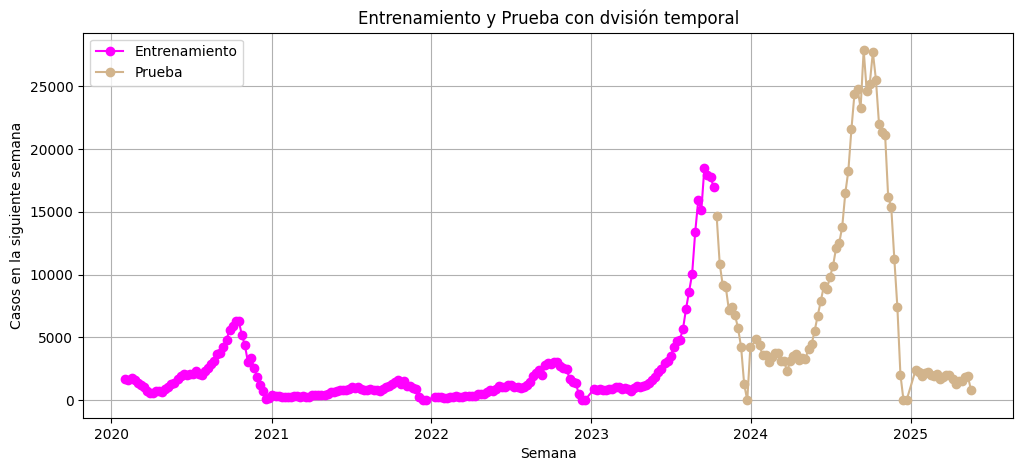

In [271]:
# gráfica

plt.figure(figsize=(12, 5))

plt.plot(
    df_train["semana"],
    df_train["casos_siguiente_semana"],
    marker="o",
    color="magenta",
    label="Entrenamiento"
)

plt.plot(
    df_test["semana"],
    df_test["casos_siguiente_semana"],
    marker="o",
    color="tan",
    label="Prueba"
)

plt.xlabel("Semana")
plt.ylabel("Casos en la siguiente semana")
plt.title("Entrenamiento y Prueba con dvisión temporal")
plt.legend()
plt.grid()

plt.show()

## **Parte 6. Matriz de confusión e interpretación**

Incluyan una matriz de confusión para analizar en qué clases acierta y en qué clases se equivoca el modelo.


Recuerden que:


* las filas representan las clases reales;
* las columnas representan las clases predichas;
* la diagonal representa los aciertos;
* los valores fuera de la diagonal representan errores.


En la interpretación, respondan:


* ¿Qué clase se predice mejor?
* ¿Qué clase se confunde más?
* ¿El modelo detecta bien las semanas de riesgo alto?
* ¿Confunde semanas de riesgo medio con riesgo bajo o alto?
* ¿Qué implicaría esto en un contexto epidemiológico?

In [272]:
# Modelo de riesgo

df_modelo["riesgo_actual"] = pd.qcut(
    df_modelo["casos_semana"],
    q=3,
    labels=["bajo", "medio", "alto"]
)

In [273]:
# Entrenamiento

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["riesgo_siguiente_semana"]

X_test = df_test[variables_predictoras]
y_test = df_test["riesgo_siguiente_semana"]

df_test["pred_naive"] = df_test["riesgo_actual"]

In [274]:
# Accuracy para modelo ingenuo

acc_naive = accuracy_score(y_test, df_test["pred_naive"])

print("Accuracy modelo ingenuo:", acc_naive)

Accuracy modelo ingenuo: 0.9012345679012346


In [275]:
# Accuracy para modelo de árbol

modelo_arbol = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, pred_arbol)

print("Accuracy árbol de decisión:", acc_arbol)

Accuracy árbol de decisión: 0.9012345679012346


In [276]:
# Accuracy para modelo Randomo Forest

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.9012345679012346


In [277]:
# Metricas

df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Árbol de decisión",
        "Random Forest"
    ],
    "accuracy": [
        acc_naive,
        acc_arbol,
        acc_rf
    ]
})

df_metricas.sort_values("accuracy")

,modelo,accuracy
0,Naive,0.901235
1,Árbol de decisión,0.901235
2,Random Forest,0.901235


In [280]:
# Defnimos para bajo, medio y alto

labels = ["bajo", "medio", "alto"]

def matriz_confusion_df(y_real, y_pred, labels):
    cm = confusion_matrix(y_real, y_pred, labels=labels)

    df_cm = pd.DataFrame(
        cm,
        index=[f"Real {l}" for l in labels],
        columns=[f"Pred {l}" for l in labels]
    )

    return df_cm

print("Matriz de confusión - Ingenuo")
display(matriz_confusion_df(y_test, df_test["pred_naive"], labels))

print("Matriz de confusión - Árbol")
display(matriz_confusion_df(y_test, pred_arbol, labels))

print("Matriz de confusión - Random Forest")
display(matriz_confusion_df(y_test, pred_rf, labels))

Matriz de confusión - Ingenuo


,Pred bajo,Pred medio,Pred alto
Real bajo,1,3,0
Real medio,0,18,3
Real alto,1,1,54


Matriz de confusión - Árbol


,Pred bajo,Pred medio,Pred alto
Real bajo,1,3,0
Real medio,0,18,3
Real alto,1,1,54


Matriz de confusión - Random Forest


,Pred bajo,Pred medio,Pred alto
Real bajo,1,1,2
Real medio,0,18,3
Real alto,1,1,54


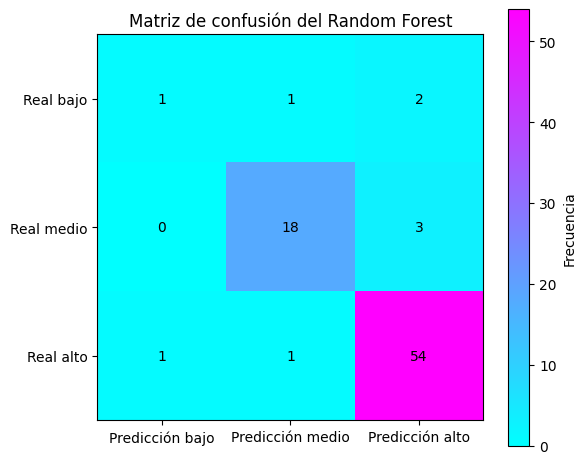

In [284]:
# Gráfica

df_cm_rf = matriz_confusion_df(y_test, pred_rf, labels)

plt.figure(figsize=(6, 5))

plt.imshow(df_cm_rf, cmap='cool')

plt.xticks(range(len(labels)), [f"Predicción {l}" for l in labels])
plt.yticks(range(len(labels)), [f"Real {l}" for l in labels])

plt.title("Matriz de confusión del Random Forest")
plt.colorbar(label="Frecuencia")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            df_cm_rf.iloc[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [286]:
# Reportes del Árbol de decisión y del Random forest

print("Reporte - Árbol de decisión")
print(classification_report(y_test, pred_arbol))

print("Reporte - Random Forest")
print(classification_report(y_test, pred_rf))

Reporte - Árbol de decisión
              precision    recall  f1-score   support

        alto       0.95      0.96      0.96        56
        bajo       0.50      0.25      0.33         4
       medio       0.82      0.86      0.84        21

    accuracy                           0.90        81
   macro avg       0.76      0.69      0.71        81
weighted avg       0.89      0.90      0.89        81

Reporte - Random Forest
              precision    recall  f1-score   support

        alto       0.92      0.96      0.94        56
        bajo       0.50      0.25      0.33         4
       medio       0.90      0.86      0.88        21

    accuracy                           0.90        81
   macro avg       0.77      0.69      0.72        81
weighted avg       0.89      0.90      0.89        81



**RESPUESTAS**

* *¿Qué clase se predice mejor?*

  El riesgo alto es el que predice mejor (Tal vez sea por el tamaño de los cortes).

* *¿Qué clase se confunde más?*

    El de riesgo bajo (por lo mismo de los cortes).

* *¿El modelo detecta bien las semanas de riesgo alto?*

    Sí, ya que abarca en gran medida el riesgo alto, en comparación del medio y del bajo (con sus respectivos).

* *¿Confunde semanas de riesgo medio con riesgo bajo o alto?*

    Es muy poco lo que se llega a confundir como riesgo medio.

* *¿Qué implicaría esto en un contexto epidemiológico?*

    Que existe un riesgo alto real, pero eso nos ayudaría para la prevención de la transmisión, por lo que es un rasgo preventivo.

.

## **Parte 7. Importancia de variables**

Para el modelo Random Forest, calculen e interpreten la importancia de variables.

Respondan:

* ¿Cuál fue la variable más importante?
* ¿Los casos actuales ($C_t$) fueron más importantes que los rezagos?
* ¿Los promedios móviles aportaron información?
* ¿El cambio semanal fue relevante?
* ¿La importancia de variables debe interpretarse como causalidad?

In [287]:
# Importancias

importancias = pd.DataFrame({
    "variable": variables_predictoras,
    "importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    "importancia",
    ascending=False
)

importancias

,variable,importancia
0,casos_semana,0.371547
1,lag_1,0.187138
5,promedio_movil_3,0.169493
6,promedio_movil_5,0.083364
2,lag_2,0.066738
7,cambio_semanal,0.045236
3,lag_3,0.034326
8,cambio_relativo,0.026351
4,lag_4,0.015808


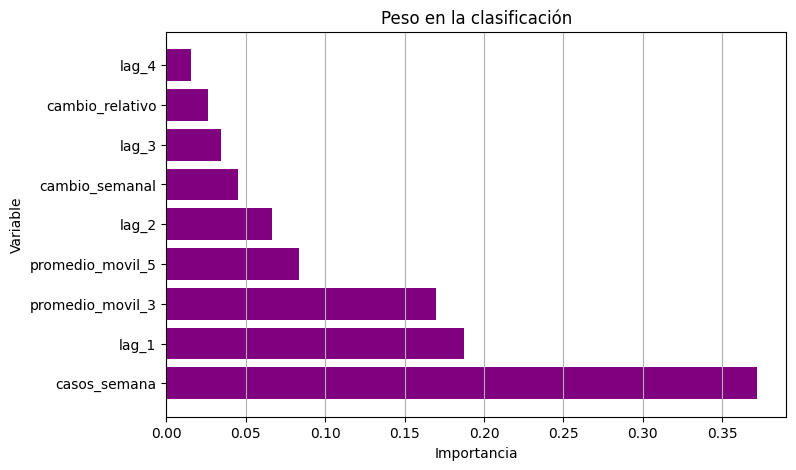

In [290]:
# Gráfica de barras

plt.figure(figsize=(8, 5))

plt.barh(
    importancias["variable"],
    importancias["importancia"],
    color="purple"
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Peso en la clasificación")
plt.grid(axis="x")

plt.show()

In [292]:
# Mapa de riesgo

mapa_riesgo = {"bajo": 0, "medio": 1, "alto": 2}

df_test["riesgo_real_num"] = df_test["riesgo_siguiente_semana"].map(mapa_riesgo)
df_test["riesgo_rf_num"] = pd.Series(pred_rf, index=df_test.index).map(mapa_riesgo)
df_test["riesgo_naive_num"] = df_test["pred_naive"].map(mapa_riesgo)

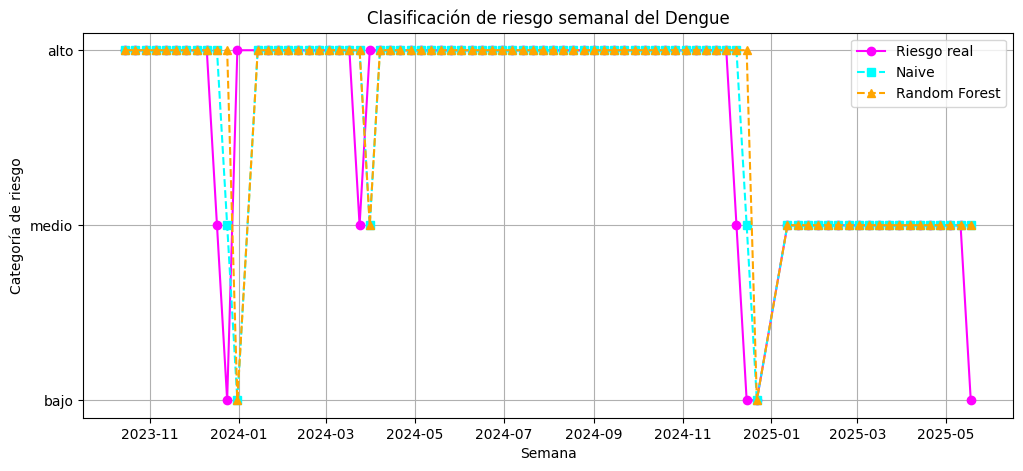

In [295]:
# Gráfica de riesgo real

plt.figure(figsize=(12, 5))

plt.plot(
    df_test["semana"],
    df_test["riesgo_real_num"],
    marker="o",
    color="magenta",
    label="Riesgo real"
)

plt.plot(
    df_test["semana"],
    df_test["riesgo_naive_num"],
    marker="s",
    linestyle="--",
    color="cyan",
    label="Naive"
)

plt.plot(
    df_test["semana"],
    df_test["riesgo_rf_num"],
    marker="^",
    linestyle="--",
    color="orange",
    label="Random Forest"
)

plt.yticks([0, 1, 2], ["bajo", "medio", "alto"])

plt.xlabel("Semana")
plt.ylabel("Categoría de riesgo")
plt.title("Clasificación de riesgo semanal del Dengue")
plt.legend()
plt.grid()

plt.show()

In [296]:
# Multiples variaciones

valores_arboles = [50, 100, 200]
valores_depth = [2, 3, 4, 5, 6]
valores_leaf = [1, 3, 5, 10]

resultados = []

for n_est in valores_arboles:
    for depth in valores_depth:
        for leaf in valores_leaf:

            modelo_temp = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=42
            )

            modelo_temp.fit(X_train, y_train)

            pred_temp = modelo_temp.predict(X_test)

            acc_temp = accuracy_score(y_test, pred_temp)

            resultados.append({
                "n_estimators": n_est,
                "max_depth": depth,
                "min_samples_leaf": leaf,
                "accuracy": acc_temp
            })

df_grid = pd.DataFrame(resultados)

df_grid.sort_values("accuracy", ascending=False).head(10)

,n_estimators,max_depth,min_samples_leaf,accuracy
0,50,2,1,0.91358
1,50,2,3,0.91358
2,50,2,5,0.91358
3,50,2,10,0.91358
7,50,3,10,0.91358
11,50,4,10,0.91358
22,100,2,5,0.91358
23,100,2,10,0.91358
27,100,3,10,0.91358
21,100,2,3,0.91358


In [297]:
# ¿Cuál es mejor?

mejor = df_grid.sort_values("accuracy", ascending=False).iloc[0]

mejor

,0
n_estimators,50.00000
max_depth,2.00000
min_samples_leaf,1.00000
accuracy,0.91358


In [299]:
# Ajuste del Random Forest

modelo_rf_final = RandomForestClassifier(
    n_estimators=int(mejor["n_estimators"]),
    max_depth=int(mejor["max_depth"]),
    min_samples_leaf=int(mejor["min_samples_leaf"]),
    random_state=42
)

modelo_rf_final.fit(X_train, y_train)

pred_rf_final = modelo_rf_final.predict(X_test)

acc_rf_final = accuracy_score(y_test, pred_rf_final)

print("Random Forest ajustado")
print("Accuracy:", acc_rf_final)

Random Forest ajustado
Accuracy: 0.9135802469135802


In [301]:
df_metricas_final = pd.DataFrame({"modelo": ["Naive", "Árbol", "Random Forest inicial", "Random Forest ajustado"],
    "accuracy": [acc_naive, acc_arbol, acc_rf, acc_rf_final]
})

df_metricas_final.sort_values("accuracy", ascending=False)

,modelo,accuracy
3,Random Forest ajustado,0.913580
0,Naive,0.901235
1,Árbol,0.901235
2,Random Forest inicial,0.901235


In [302]:
df_cm_final = matriz_confusion_df(
    y_test,
    pred_rf_final,
    labels
)

df_cm_final

,Pred bajo,Pred medio,Pred alto
Real bajo,1,1,2
Real medio,0,18,3
Real alto,0,1,55


In [303]:
print(classification_report(y_test, pred_rf_final))

              precision    recall  f1-score   support

        alto       0.92      0.98      0.95        56
        bajo       1.00      0.25      0.40         4
       medio       0.90      0.86      0.88        21

    accuracy                           0.91        81
   macro avg       0.94      0.70      0.74        81
weighted avg       0.92      0.91      0.90        81



**RESPUESTAS**

* ¿Cuál fue la variable más importante?

    Se le da un peso mayor a la variable de casos semana.

* ¿Los casos actuales ($C_t$) fueron más importantes que los rezagos?

    Sí, ya que se le dio un peso mayor a la variable de casos semana, mientras que los rezagos, solo el nivel 1 fue el que más peso se le dio después de casos semana.

* ¿Los promedios móviles aportaron información?

    Sí, ya que fueron las siguientes variables con mayor peso para el programa, lo que implica una buena aportación de información.


* ¿El cambio semanal fue relevante?

    Casi no, tiene un peso ligero, pero no fue tan importante.

* ¿La importancia de variables debe interpretarse como causalidad?

    No, ya que estas influyen y pueden modelar casi bien lo que puede pasar.

.

## **Parte 8. Conclusiones finales**

El notebook debe cerrar con una sección de conclusiones.


Respondan de forma clara:


1. ¿Qué se observó en la serie nacional de dengue?
2. ¿Qué modelo funcionó mejor para predecir casos?
3. ¿Qué modelo funcionó mejor para clasificar riesgo?
4. ¿El modelo más complejo fue siempre el mejor?
5. ¿Qué tan útil fue el modelo ingenuo?
6. ¿Qué variables fueron más importantes?
7. ¿Qué limitaciones tiene el análisis?
8. ¿Qué información adicional podría mejorar los modelos?

**RESPUESTAS**

1. ¿Qué se observó en la serie nacional de dengue?

    Yo pude notar que los contagios de dengue aumentaban considerabelmente en la temporada de otoño, y que en un año (2024), hubo un incrmeneto muy grande a comparación de otros años.

2. ¿Qué modelo funcionó mejor para predecir casos?

    En cierta medida, sí, ya que predijo correctamente los futuros casos que se registraron, por lo que sí feu un modelomcon buena predicción.

3. ¿Qué modelo funcionó mejor para clasificar riesgo?

    Siento que para este caso, el modelo ingenuo fue el que hizo mejor clasificación que los demás.

4. ¿El modelo más complejo fue siempre el mejor?

    No, con relación al comentario anterior, el mejor fue el más sencillo de todos, por lo que en este caso, el modelo más complejo no aporto gran infromación o se acoplo a la situación más de lo que lo hicieron los demás.

5. ¿Qué tan útil fue el modelo ingenuo?

    Creo que fue buena, sino es que excelente, ya que se adapto más a la realidad respecto a los demás.

6. ¿Qué variables fueron más importantes?

    Los casos de la semana, el lag de nivel 1 y el promedio movil de nivel 3. Las demás tuvieron un peso más bajo.

7. ¿Qué limitaciones tiene el análisis?

    Que no toma en cuenta cuestiones atipicas o cosas humanas, ya que modela de un modo simplista, lo que limita la exactitud de la propagación de la misma.

8. ¿Qué información adicional podría mejorar los modelos?

    Siento que sería difícil, ya que serían cuestiones más externas, como cosas humanas, algo que podría decirse que es muy aleatorio, de ahí en fuera no logro ver algo que pueda mejorar más a los modelos.